In [4]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

from sklearn.preprocessing import MinMaxScaler

In [5]:
# Reading csv's and shapefile
al_nri = pd.read_csv("NRI_Table_CensusTracts_Alaska.csv")
al_svi = pd.read_csv("Alaska.csv")
cali_nri = pd.read_csv("NRI_Table_CensusTracts_California.csv")
cali_svi = pd.read_csv("California.csv")
tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')
tracts = tracts.replace(-9999, np.nan)
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

In [7]:
# Prepare merge keys
al_nri['STCNTY'] = al_nri['STCOFIPS'].astype(str)
cali_nri['STCNTY'] = cali_nri['STCOFIPS'].astype(str)
al_svi['STCNTY'] = al_svi['STCNTY'].astype(str)
cali_svi['STCNTY'] = cali_svi['STCNTY'].astype(str)

# Remove duplicate keys from SVI
al_svi_clean = al_svi.drop_duplicates(subset='STCNTY')
cali_svi_clean = cali_svi.drop_duplicates(subset='STCNTY')

# Merge
al_complete_data = pd.merge(
    al_nri, al_svi_clean, on='STCNTY', suffixes=('', '_right'), validate='many_to_one'
)

cali_complete_data = pd.merge(
    cali_nri, cali_svi_clean, on='STCNTY', suffixes=('', '_right'), validate='many_to_one'
)

In [8]:
# Alaska numeric columns
al_num_cols = al_complete_data.select_dtypes(include=["int64", "float64"]).columns

# California numeric columns
cali_num_cols = cali_complete_data.select_dtypes(include=["int64", "float64"]).columns

# Fill NA with median
al_complete_data[al_num_cols] = al_complete_data[al_num_cols].fillna(
    al_complete_data[al_num_cols].median()
)

cali_complete_data[cali_num_cols] = cali_complete_data[cali_num_cols].fillna(
    cali_complete_data[cali_num_cols].median()
)

In [9]:
# This was used to fix a warning of the files being fragmented
al_complete_data = al_complete_data.drop_duplicates(subset="TRACTFIPS").copy()
cali_complete_data = cali_complete_data.drop_duplicates(subset="TRACTFIPS").copy()

In [10]:
print(
    nri_dictionary[
        nri_dictionary["Field Name"].str.contains(
            "WFIR_RISKS|WFIR_EXPT|WFIR_AFREQ|WFIR_HLRP|CWAV_RISKS|CWAV_EXPT|CWAV_AFREQ|CWAV_HLRP|SOVI_SCORE|RESL_SCORE"
        )
    ][["Field Name", "Field Alias"]]
)

     Field Name                                   Field Alias
35   SOVI_SCORE                  Social Vulnerability - Score
38   RESL_SCORE                  Community Resilience - Score
88   CWAV_AFREQ              Cold Wave - Annualized Frequency
93    CWAV_EXPT                  Cold Wave - Exposure - Total
96    CWAV_HLRP  Cold Wave - Historic Loss Ratio - Population
111  CWAV_RISKS      Cold Wave - Hazard Type Risk Index Score
418  WFIR_AFREQ               Wildfire - Annualized Frequency
423   WFIR_EXPT                   Wildfire - Exposure - Total
426   WFIR_HLRP   Wildfire - Historic Loss Ratio - Population
441  WFIR_RISKS       Wildfire - Hazard Type Risk Index Score


In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaler100 = MinMaxScaler(feature_range=(0,100))

In [12]:
# California Risk Calculations

# Normalize SOVI and RESL
cali_complete_data["SOVI_norm"] = scaler.fit_transform(cali_complete_data[["SOVI_SCORE"]])
cali_complete_data["RESL_norm"] = scaler.fit_transform(cali_complete_data[["RESL_SCORE"]])

# Wildfire hazard calculation
cali_complete_data["WFIR_hazard_raw"] = (
    cali_complete_data["WFIR_EXPT"] *
    cali_complete_data["WFIR_AFREQ"] *
    cali_complete_data["WFIR_HLRP"]
)

# Fill missing values
cali_complete_data["WFIR_hazard_raw"] = cali_complete_data["WFIR_hazard_raw"].fillna(
    cali_complete_data["WFIR_hazard_raw"].median()
)

# Normalize hazard
cali_complete_data["WFIR_hazard_norm"] = scaler.fit_transform(
    cali_complete_data[["WFIR_hazard_raw"]]
)

# Final risk model
cali_complete_data["new_WFIR_RISKS"] = (
    0.40 * cali_complete_data["WFIR_hazard_norm"] +
    0.45 * cali_complete_data["SOVI_norm"] -
    0.15 * cali_complete_data["RESL_norm"]
).clip(lower=0)

# Scale to 0–100
cali_complete_data["new_WFIR_RISKS"] = scaler100.fit_transform(
    cali_complete_data[["new_WFIR_RISKS"]]
)

# Merge with shapefile
cali_tracts_clean = tracts.to_crs("ESRI:102003")
cali_tracts_clean["TRACTFIPS"] = cali_tracts_clean["TRACTFIPS"].astype(str)
cali_complete_data["TRACTFIPS"] = cali_complete_data["TRACTFIPS"].astype(str)

cali_tracts_clean = cali_tracts_clean.merge(
    cali_complete_data[["TRACTFIPS", "WFIR_RISKS", "new_WFIR_RISKS"]],
    on="TRACTFIPS",
    how="left"
)

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaler100 = MinMaxScaler(feature_range=(0,100))

In [14]:
# Alaska Risk Calculations

# Normalize SOVI and RESL
al_complete_data["SOVI_norm"] = scaler.fit_transform(al_complete_data[["SOVI_SCORE"]])
al_complete_data["RESL_norm"] = scaler.fit_transform(al_complete_data[["RESL_SCORE"]])

# Cold Wave hazard calculation
al_complete_data["CWAV_hazard_raw"] = (
    al_complete_data["CWAV_EXPT"] *
    al_complete_data["CWAV_AFREQ"] *
    al_complete_data["CWAV_HLRP"]
)

# Fill NA values
al_complete_data["CWAV_hazard_raw"] = al_complete_data["CWAV_hazard_raw"].fillna(
    al_complete_data["CWAV_hazard_raw"].median()
)

# Normalize to 0–1
al_complete_data["CWAV_hazard_norm"] = scaler.fit_transform(
    al_complete_data[["CWAV_hazard_raw"]]
)

# Risk equation
al_complete_data["new_CWAV_RISKS"] = (
    0.40 * al_complete_data["CWAV_hazard_norm"] +
    0.45 * al_complete_data["SOVI_norm"] -
    0.15 * al_complete_data["RESL_norm"]
).clip(lower=0)

# Scale to 0–100
al_complete_data["new_CWAV_RISKS"] = scaler100.fit_transform(
    al_complete_data[["new_CWAV_RISKS"]]
)

# Prepare for mapping
al_tracts_clean = tracts.to_crs("ESRI:102003")
al_tracts_clean["TRACTFIPS"] = al_tracts_clean["TRACTFIPS"].astype(str)
al_complete_data["TRACTFIPS"] = al_complete_data["TRACTFIPS"].astype(str)

# Merge for plotting
al_tracts_clean = al_tracts_clean.merge(
    al_complete_data[["TRACTFIPS", "CWAV_RISKS", "new_CWAV_RISKS"]],
    on="TRACTFIPS",
    how="left"
)

In [24]:
# Clean TRACTFIPS in both dataframes
cali_complete_data["TRACTFIPS"] = (
    cali_complete_data["TRACTFIPS"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
    .str.zfill(11)
)

ca_tracts_clean["TRACTFIPS"] = (
    ca_tracts_clean["TRACTFIPS"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
    .str.zfill(11)
)

In [25]:
# Prepare shapefile for California
ca_tracts_clean = tracts.to_crs("ESRI:102003")

# Make sure keys match
ca_tracts_clean["TRACTFIPS"] = ca_tracts_clean["TRACTFIPS"].astype(str)
cali_complete_data["TRACTFIPS"] = cali_complete_data["TRACTFIPS"].astype(str)

# Merge California data into shapefile
ca_tracts_clean = ca_tracts_clean.merge(
    cali_complete_data[["TRACTFIPS", "WFIR_RISKS", "new_WFIR_RISKS"]],
    on="TRACTFIPS",
    how="left"
)

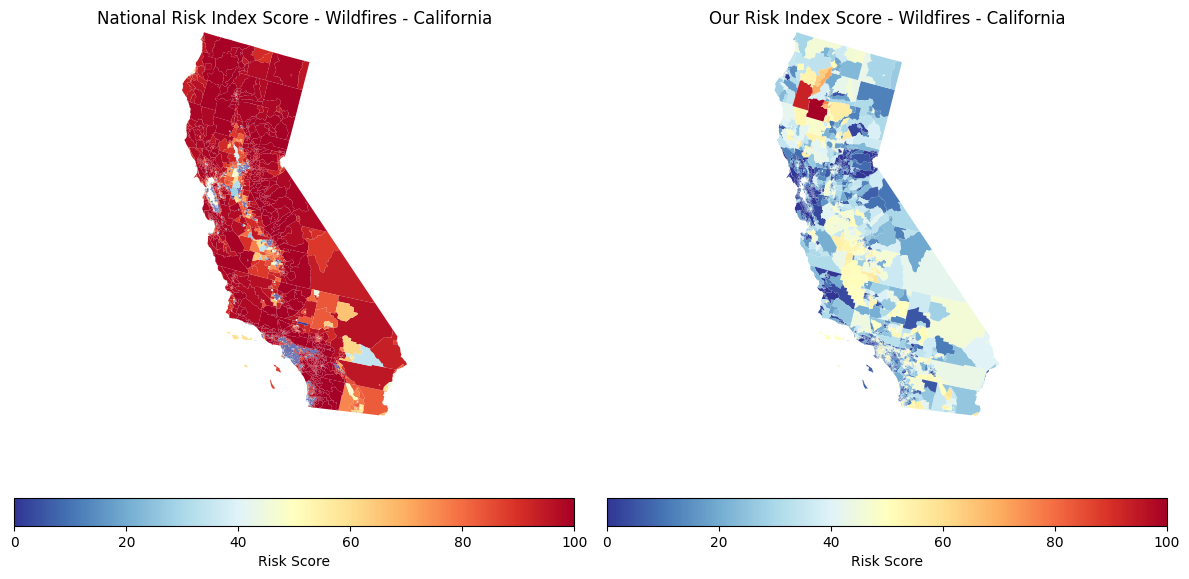

In [26]:
# Creates map space for 2 plots
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Selected state
state_name = "California"

# Filters data to only include California
state_map = ca_tracts_clean[ca_tracts_clean["STATE"].str.lower() == state_name.lower()]

# This plots the original NRI risk for wildfires
state_map.plot(column='WFIR_RISKS_x', ax=ax[0], legend=True,
                linewidth=0.1, cmap="RdYlBu_r",
                legend_kwds={'label': "Risk Score", 'orientation': "horizontal"},
                missing_kwds={'color': "lightgrey", 'label': "No Data"})

# This adjusts the padding and how big it is as well as some visuals
minx, miny, maxx, maxy = state_map.total_bounds
padding = 0.5
ax[0].set_xlim(minx-padding, maxx+padding)
ax[0].set_ylim(miny-padding, maxy+padding)
ax[0].set_title("National Risk Index Score - Wildfires - California")
ax[0].set_axis_off()

# This plots our risk for wildfires
state_map.plot(column='new_WFIR_RISKS', ax=ax[1], legend=True,
                linewidth=0.1, cmap="RdYlBu_r",
                legend_kwds={'label': "Risk Score", 'orientation': "horizontal"},
                missing_kwds={'color': "lightgrey", 'label': "No Data"})

# This adjusts the padding and how big it is as well as some visuals
ax[1].set_xlim(minx-padding, maxx+padding)
ax[1].set_ylim(miny-padding, maxy+padding)
ax[1].set_title("Our Risk Index Score - Wildfires - California")
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

In [21]:
# Group by county using the correct dataframe name
ca_counties_fire = cali_complete_data.groupby('COUNTY')[['WFIR_RISKS', 'new_WFIR_RISKS']].mean()

# Top 10 and bottom 10
ca_counties_fire_top = ca_counties_fire.nlargest(10, 'new_WFIR_RISKS')
ca_counties_fire_bottom = ca_counties_fire.nsmallest(10, 'new_WFIR_RISKS')

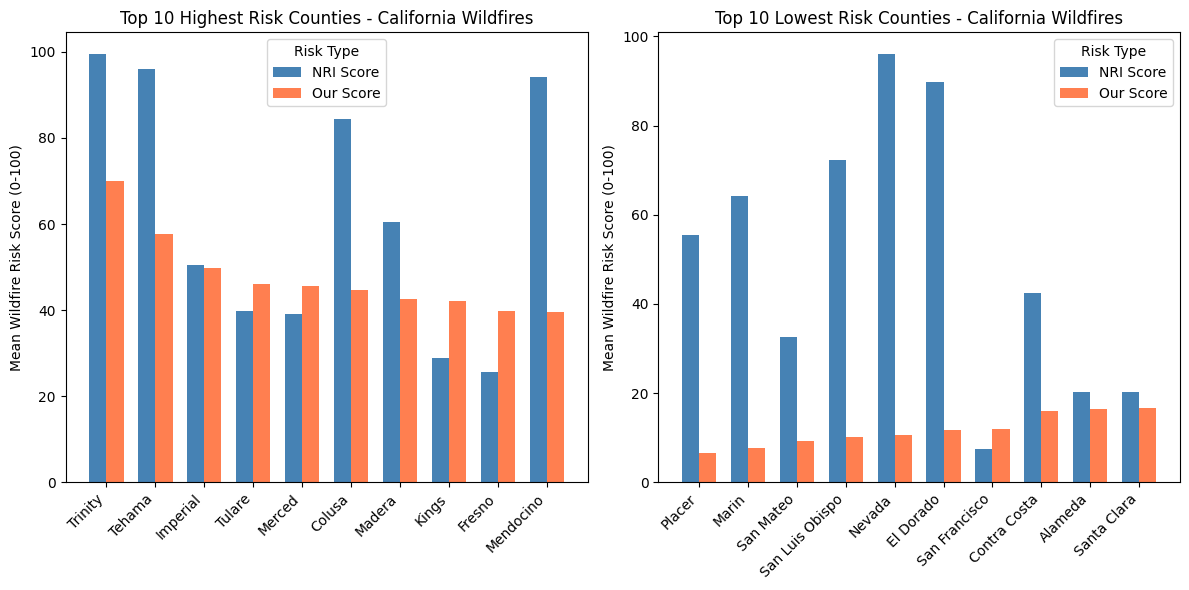

In [23]:
# This groups the data by counties by the mean of the NRI wildfire risk and our risk
ca_counties_fire = cali_complete_data.groupby('COUNTY')[['WFIR_RISKS', 'new_WFIR_RISKS']].mean()

# These filter to top 10 and bottom 10 so the bar chart is actually readable
ca_counties_fire_top = ca_counties_fire.nlargest(10, 'new_WFIR_RISKS')
ca_counties_fire_bottom = ca_counties_fire.nsmallest(10, 'new_WFIR_RISKS')

# Makes plot space
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Top 10 highest risk counties
x = np.arange(len(ca_counties_fire_top))
width = 0.35
axes[0].bar(x - width/2, ca_counties_fire_top["WFIR_RISKS"], width, label="NRI Score", color="steelblue")
axes[0].bar(x + width/2, ca_counties_fire_top["new_WFIR_RISKS"], width, label="Our Score", color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(ca_counties_fire_top.index, rotation=45, ha='right')
axes[0].set_ylabel("Mean Wildfire Risk Score (0-100)")
axes[0].set_title("Top 10 Highest Risk Counties - California Wildfires")
axes[0].legend(title="Risk Type")

# Top 10 lowest risk counties
x = np.arange(len(ca_counties_fire_bottom))
axes[1].bar(x - width/2, ca_counties_fire_bottom["WFIR_RISKS"], width, label="NRI Score", color="steelblue")
axes[1].bar(x + width/2, ca_counties_fire_bottom["new_WFIR_RISKS"], width, label="Our Score", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(ca_counties_fire_bottom.index, rotation=45, ha='right')
axes[1].set_ylabel("Mean Wildfire Risk Score (0-100)")
axes[1].set_title("Top 10 Lowest Risk Counties - California Wildfires")
axes[1].legend(title="Risk Type")

plt.tight_layout()
plt.show()

In [32]:
print([col for col in cali_complete_data.columns if "ERQK" in col])

['ERQK_EVNTS', 'ERQK_AFREQ', 'ERQK_EXP_AREA', 'ERQK_EXPB', 'ERQK_EXPP', 'ERQK_EXPPE', 'ERQK_EXPT', 'ERQK_HLRB', 'ERQK_HLRP', 'ERQK_HLRR', 'ERQK_EALB', 'ERQK_EALP', 'ERQK_EALPE', 'ERQK_EALT', 'ERQK_EALS', 'ERQK_EALR', 'ERQK_ALRB', 'ERQK_ALRP', 'ERQK_ALR_NPCTL', 'ERQK_RISKV', 'ERQK_RISKS', 'ERQK_RISKR', 'ERQK_hazard_raw', 'ERQK_hazard_norm', 'new_ERQK_RISKS']


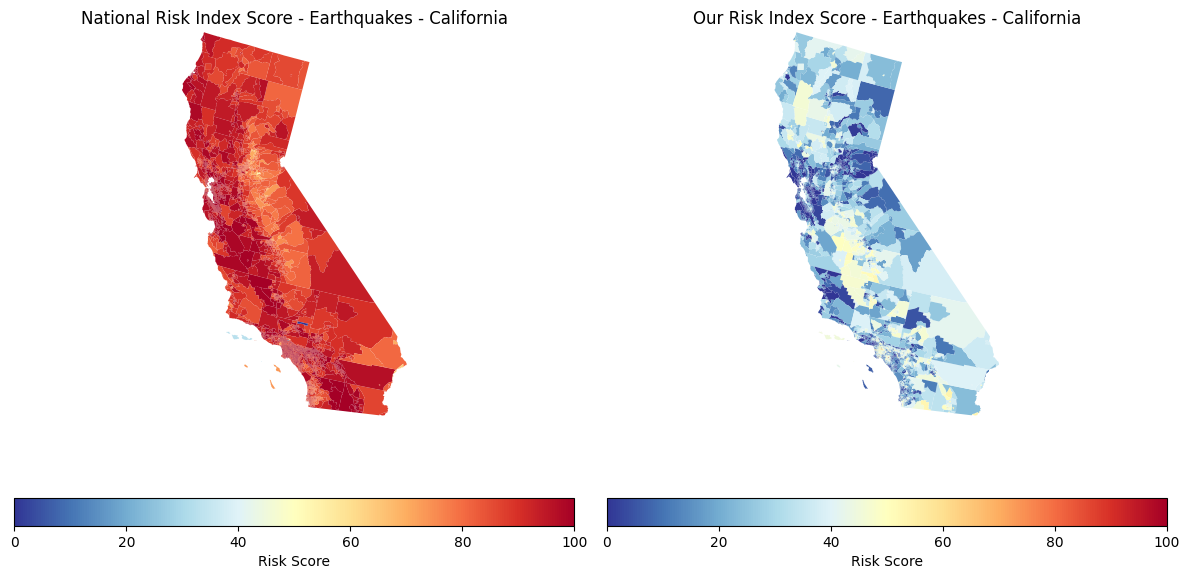

In [34]:
# Creates map space for 2 plots
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Selected state
state_name = "California"

# Filters data to only include California
state_map = ca_tracts_clean[ca_tracts_clean["STATE"].str.lower() == state_name.lower()]

# This plots the original NRI risk for earthquakes
state_map.plot(column='ERQK_RISKS_x', ax=ax[0], legend=True,
                linewidth=0.1, cmap="RdYlBu_r",
                legend_kwds={'label': "Risk Score", 'orientation': "horizontal"},
                missing_kwds={'color': "lightgrey", 'label': "No Data"})

# This adjusts the padding and how big it is as well as some visuals
minx, miny, maxx, maxy = state_map.total_bounds
padding = 0.5
ax[0].set_xlim(minx-padding, maxx+padding)
ax[0].set_ylim(miny-padding, maxy+padding)
ax[0].set_title("National Risk Index Score - Earthquakes - California")
ax[0].set_axis_off()

# This plots our risk for earthquakes
state_map.plot(column='new_ERQK_RISKS', ax=ax[1], legend=True,
                linewidth=0.1, cmap="RdYlBu_r",
                legend_kwds={'label': "Risk Score", 'orientation': "horizontal"},
                missing_kwds={'color': "lightgrey", 'label': "No Data"})

# This adjusts the padding and how big it is as well as some visuals
minx, miny, maxx, maxy = state_map.total_bounds
ax[1].set_xlim(minx-padding, maxx+padding)
ax[1].set_ylim(miny-padding, maxy+padding)
ax[1].set_title("Our Risk Index Score - Earthquakes - California")
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

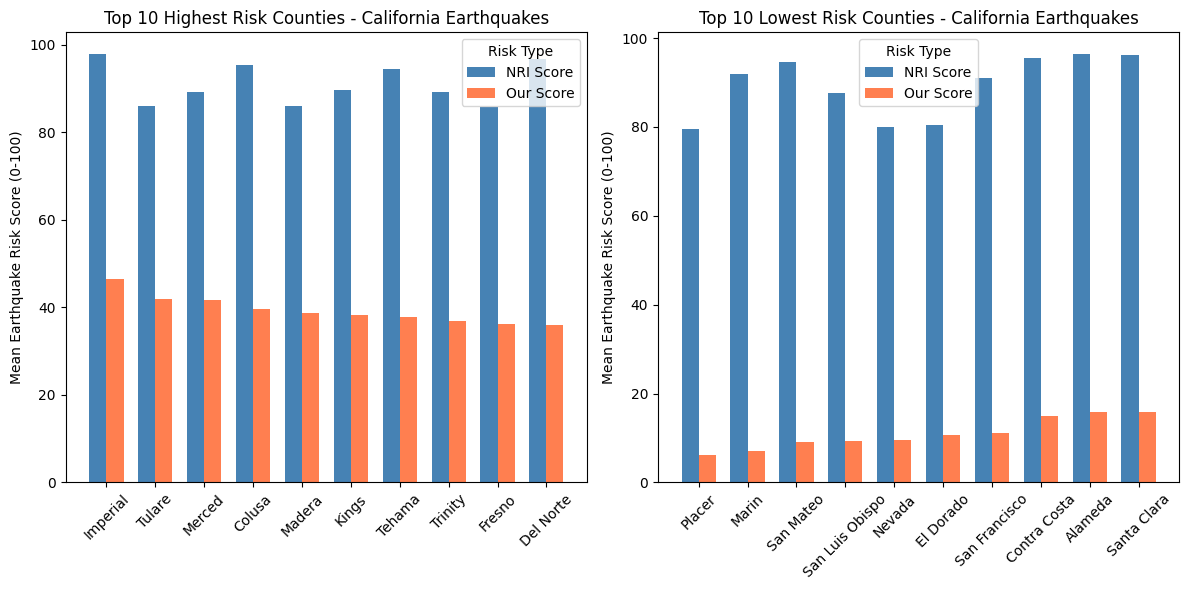

In [36]:
# This groups the data by counties by the mean of the NRI risk and our risk
ca_counties_eq = cali_complete_data.groupby('COUNTY')[['ERQK_RISKS', 'new_ERQK_RISKS']].mean()

# These filter to top 10 and bottom 10 so the bar chart is actually readable and not too congested
ca_counties_eq_top = ca_counties_eq.nlargest(10, 'new_ERQK_RISKS')
ca_counties_eq_bottom = ca_counties_eq.nsmallest(10, 'new_ERQK_RISKS')

# Makes plot space
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Sets the arrangements and what variables are on which axis as well as labels and colors
x = np.arange(len(ca_counties_eq_top))
width = 0.35
axes[0].bar(x - width/2, ca_counties_eq_top["ERQK_RISKS"], width, label="NRI Score", color="steelblue")
axes[0].bar(x + width/2, ca_counties_eq_top["new_ERQK_RISKS"], width, label="Our Score", color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(ca_counties_eq_top.index, rotation=45)
axes[0].set_ylabel("Mean Earthquake Risk Score (0-100)")
axes[0].set_title("Top 10 Highest Risk Counties - California Earthquakes")
axes[0].legend(title="Risk Type")

# Sets the arrangements and what variables are on which axis as well as labels and colors
x = np.arange(len(ca_counties_eq_bottom))
axes[1].bar(x - width/2, ca_counties_eq_bottom["ERQK_RISKS"], width, label="NRI Score", color="steelblue")
axes[1].bar(x + width/2, ca_counties_eq_bottom["new_ERQK_RISKS"], width, label="Our Score", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(ca_counties_eq_bottom.index, rotation=45)
axes[1].set_ylabel("Mean Earthquake Risk Score (0-100)")
axes[1].set_title("Top 10 Lowest Risk Counties - California Earthquakes")
axes[1].legend(title="Risk Type")

plt.tight_layout()
plt.show()

In [39]:
# Prepare Alaska shapefile
ak_tracts_clean = tracts.to_crs("ESRI:102003").copy()

# Fix FIPS keys
ak_tracts_clean["TRACTFIPS"] = (
    ak_tracts_clean["TRACTFIPS"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
    .str.zfill(11)
)

al_complete_data["TRACTFIPS"] = (
    al_complete_data["TRACTFIPS"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
    .str.zfill(11)
)

# Merge Alaska data into shapefile
ak_tracts_clean = ak_tracts_clean.merge(
    al_complete_data[["TRACTFIPS", "CWAV_RISKS", "new_CWAV_RISKS"]],
    on="TRACTFIPS",
    how="left"
)

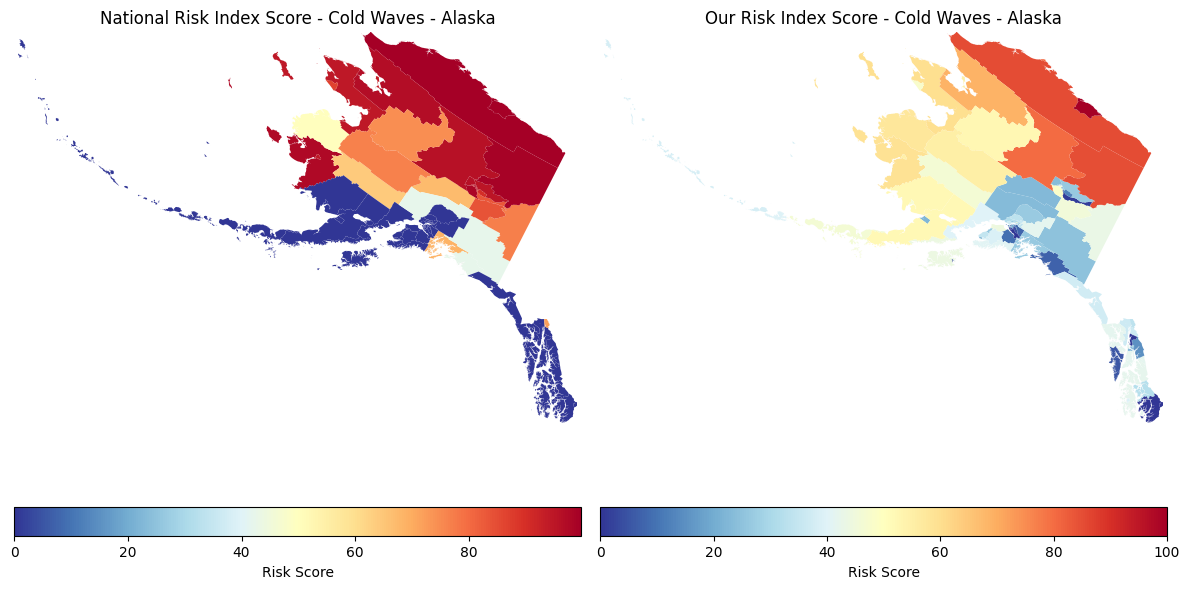

In [40]:
# Creates map space for 2 plots
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Selected state
state_name = "Alaska"

# Filters data to only include Alaska
state_map = ak_tracts_clean[ak_tracts_clean["STATE"].str.lower() == state_name.lower()]

# NRI Alaska Cold Wave Risk
state_map.plot(column='CWAV_RISKS_x', ax=ax[0], legend=True,
                linewidth=0.1, cmap="RdYlBu_r",
                legend_kwds={'label': "Risk Score", 'orientation': "horizontal"},
                missing_kwds={'color': "lightgrey", 'label': "No Data"})

# This adjusts the padding and how big it is as well as some visuals
minx, miny, maxx, maxy = state_map.total_bounds
padding = 0.5
ax[0].set_xlim(minx-padding, maxx+padding)
ax[0].set_ylim(miny-padding, maxy+padding)
ax[0].set_title("National Risk Index Score - Cold Waves - Alaska")
ax[0].set_axis_off()

# This plots our risk for cold waves
state_map.plot(column='new_CWAV_RISKS', ax=ax[1], legend=True,
                linewidth=0.1, cmap="RdYlBu_r",
                legend_kwds={'label': "Risk Score", 'orientation': "horizontal"},
                missing_kwds={'color': "lightgrey", 'label': "No Data"})

# This adjusts the padding and how big it is as well as some visuals
minx, miny, maxx, maxy = state_map.total_bounds
ax[1].set_xlim(minx-padding, maxx+padding)
ax[1].set_ylim(miny-padding, maxy+padding)
ax[1].set_title("Our Risk Index Score - Cold Waves - Alaska")
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

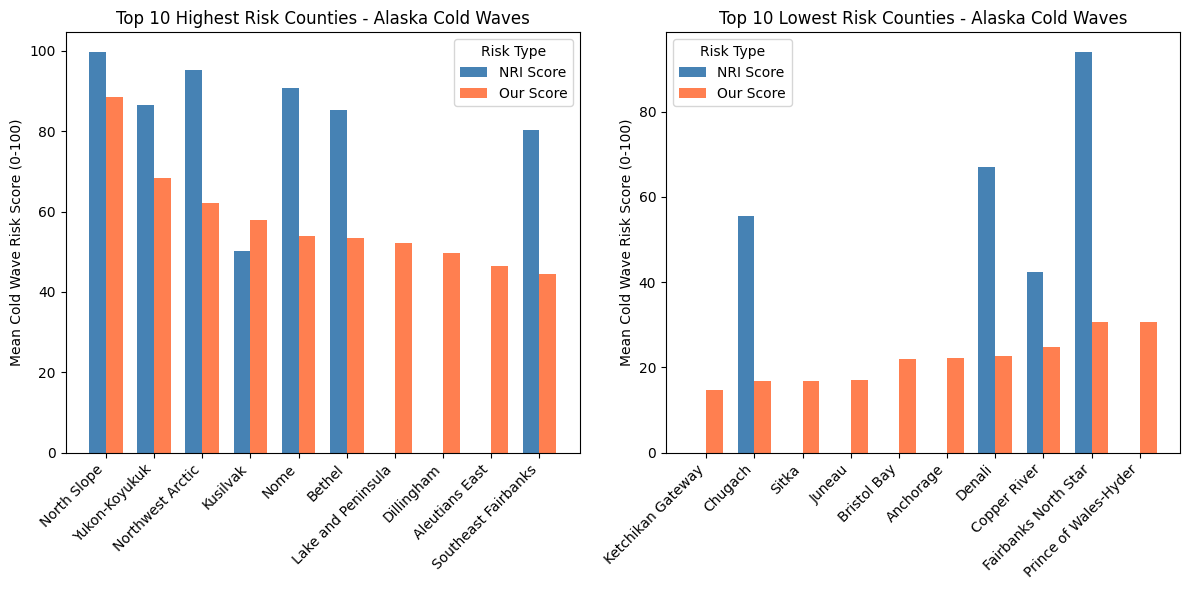

In [41]:
# This groups the data by counties by the mean of the NRI risk and our risk
ak_counties_cold = al_complete_data.groupby('COUNTY')[['CWAV_RISKS', 'new_CWAV_RISKS']].mean()

# Top 10 and bottom 10
ak_counties_cold_top = ak_counties_cold.nlargest(10, 'new_CWAV_RISKS')
ak_counties_cold_bottom = ak_counties_cold.nsmallest(10, 'new_CWAV_RISKS')

# Makes plot space
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Top 10 highest risk counties
x = np.arange(len(ak_counties_cold_top))
width = 0.35
axes[0].bar(x - width/2, ak_counties_cold_top["CWAV_RISKS"], width, label="NRI Score", color="steelblue")
axes[0].bar(x + width/2, ak_counties_cold_top["new_CWAV_RISKS"], width, label="Our Score", color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(ak_counties_cold_top.index, rotation=45, ha='right')
axes[0].set_ylabel("Mean Cold Wave Risk Score (0-100)")
axes[0].set_title("Top 10 Highest Risk Counties - Alaska Cold Waves")
axes[0].legend(title="Risk Type")

# Bottom 10 lowest risk counties
x = np.arange(len(ak_counties_cold_bottom))
axes[1].bar(x - width/2, ak_counties_cold_bottom["CWAV_RISKS"], width, label="NRI Score", color="steelblue")
axes[1].bar(x + width/2, ak_counties_cold_bottom["new_CWAV_RISKS"], width, label="Our Score", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(ak_counties_cold_bottom.index, rotation=45, ha='right')
axes[1].set_ylabel("Mean Cold Wave Risk Score (0-100)")
axes[1].set_title("Top 10 Lowest Risk Counties - Alaska Cold Waves")
axes[1].legend(title="Risk Type")

plt.tight_layout()
plt.show()